In [152]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

##  Data preprocessing

In [153]:
df = pd.read_csv("c:/Users/lenovo/Downloads/AI_CA3/Grades.csv")


In [154]:
for column in df.columns:
    if df[column].dtype == 'object':  
        count = (df[column] == "other").sum()
        if count > 0:
            print(f"{column}: {count} times")


motherJob: 142 times
fatherJob: 217 times
reason: 37 times


In [155]:
df.drop(columns=["motherJob", "fatherJob" , "reason"], inplace=True)


In [156]:
categorical_columns = [
    'sex', 'address', 'universitySupport',
    'paid', 'higher', 'internet', 'romantic'
]

for col in categorical_columns:
    df[col] = df[col].astype('category').cat.codes

for col in categorical_columns:
    print(f"{col} unique codes:", df[col].unique())

df["university"] = df["university"].astype("category").cat.codes


sex unique codes: [0 1]
address unique codes: [1 0]
universitySupport unique codes: [1 0]
paid unique codes: [0 1]
higher unique codes: [1 0]
internet unique codes: [0 1]
romantic unique codes: [0 1]


## Normalization

In [157]:
df["age"] = (df["age"] - df["age"].min()) / (df["age"].max() - df["age"].min())

print(df["age"].head(5))

0    0.428571
1    0.285714
2    0.000000
3    0.000000
4    0.142857
Name: age, dtype: float64


In [158]:
#print(df[["EPSGrade", "DSGrade", "finalGrade"]].corr())

df["EPSGrade"] = (df["EPSGrade"] - df["EPSGrade"].min()) / (df["EPSGrade"].max() - df["EPSGrade"].min())

df["DSGrade"] = (df["DSGrade"] - df["DSGrade"].min()) / (df["DSGrade"].max() - df["DSGrade"].min())

#print(df[["EPSGrade", "DSGrade"]].describe())


In [159]:
print(df["finalGrade"].head())

def grade_to_class(grade):
    if grade > 17:
        return 0
    elif grade > 14:
        return 1
    elif grade > 10:
        return 2
    else:
        return 3

df["finalGrade_new"] = df["finalGrade"].apply(grade_to_class)

df.drop(columns=["finalGrade"], inplace=True)
df.rename(columns={"finalGrade_new": "finalGrade"}, inplace=True)

print(df["finalGrade"].unique())


0     6
1     6
2    10
3    15
4    10
Name: finalGrade, dtype: int64
[3 1 2 0]


## Train-Test Split

In [160]:
X = df.drop(columns=["finalGrade"])
y = df["finalGrade"] 

X = X.to_numpy()
y = y.to_numpy()

np.random.seed(42)
indices = np.random.permutation(len(X))
split_index = int(0.8 * len(X))

X_train = X[indices[:split_index]]
X_test = X[indices[split_index:]]
y_train = y[indices[:split_index]]
y_test = y[indices[split_index:]]


print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (317, 21)
y_train shape: (317,)
X_test shape: (80, 21)
y_test shape: (80,)


In [161]:
#plt.hist(df["absences"], bins=20, edgecolor='black')
#plt.title("Distribution of Absences")
#plt.xlabel("Number of Absences")
#plt.ylabel("Frequency")
#plt.show()

#print(df["absences"].describe())


#df["absences"] = np.log1p(df["absences"])  # log(1 + x)

#plt.hist(df["absences"], bins=20, edgecolor='black')
#plt.title("Distribution of Absences")
#plt.xlabel("Number of Absences")
#plt.ylabel("Frequency")
#plt.show()

#print(df["absences"].describe())


## Naive Bayes


In [162]:
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))


Accuracy: 0.7125


### Evaluation of Naive Bayes

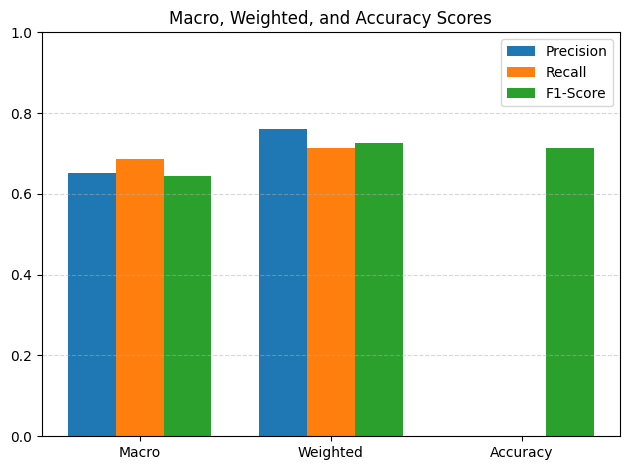

In [163]:
report = classification_report(y_test, y_pred, output_dict=True)

averages = ["macro avg", "weighted avg"]

labels = ["precision", "recall", "f1-score"]

data = {
    label: [report[avg][label] for avg in averages]
    for label in labels
}

data["f1-score"].append(report["accuracy"]) 

x_labels = ["Macro", "Weighted", "Accuracy"]
x = np.arange(len(x_labels))
width = 0.25

fig, ax = plt.subplots()
ax.bar(x - width, data["precision"] + [0], width, label="Precision")
ax.bar(x, data["recall"] + [0], width, label="Recall")
ax.bar(x + width, data["f1-score"], width, label="F1-Score")

ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_ylim(0, 1)
ax.set_title("Macro, Weighted, and Accuracy Scores")
ax.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


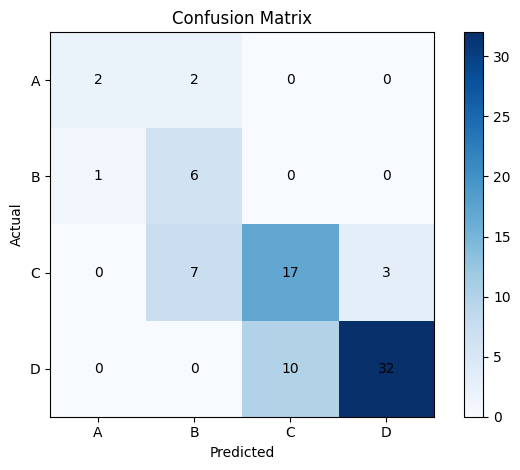

In [164]:
cm = confusion_matrix(y_test, y_pred)

labels = ["A", "B", "C", "D"]

fig, ax = plt.subplots()
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.colorbar(im)
plt.tight_layout()
plt.show()


## Decision Tree

In [165]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier , plot_tree
from sklearn.model_selection import GridSearchCV

model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

model.fit(X_train, y_train)
y_pred = model.predict(X_test)

param_grid = {
    "max_depth": [3, 5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 3, 5],
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring="f1_weighted"
)

grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

print("Best Parameters:", grid_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))

Best Parameters: {'max_depth': 3, 'min_samples_leaf': 1, 'min_samples_split': 2}
Accuracy: 0.825


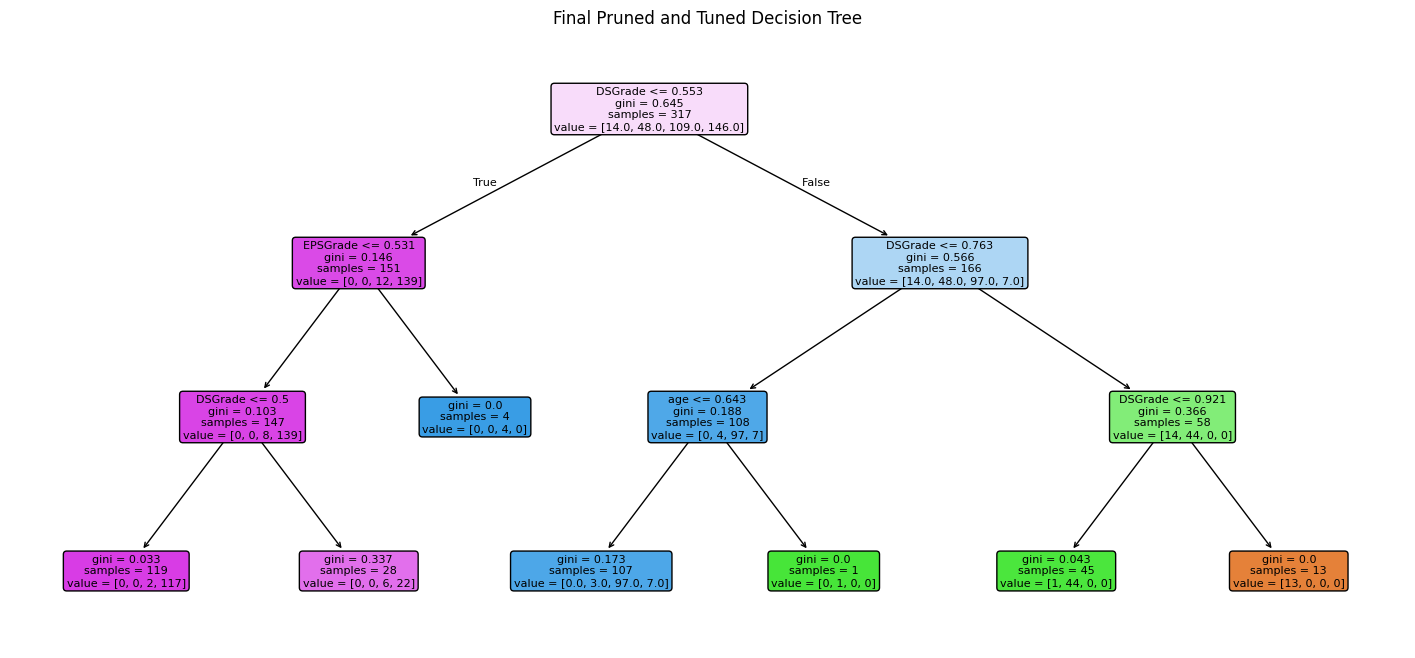

In [166]:
plt.figure(figsize=(18, 8))
plot_tree(
    best_model,
    feature_names=df.drop(columns=["finalGrade"]).columns,
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("Final Pruned and Tuned Decision Tree")
plt.show()


###  Evaluation of Decision Tree

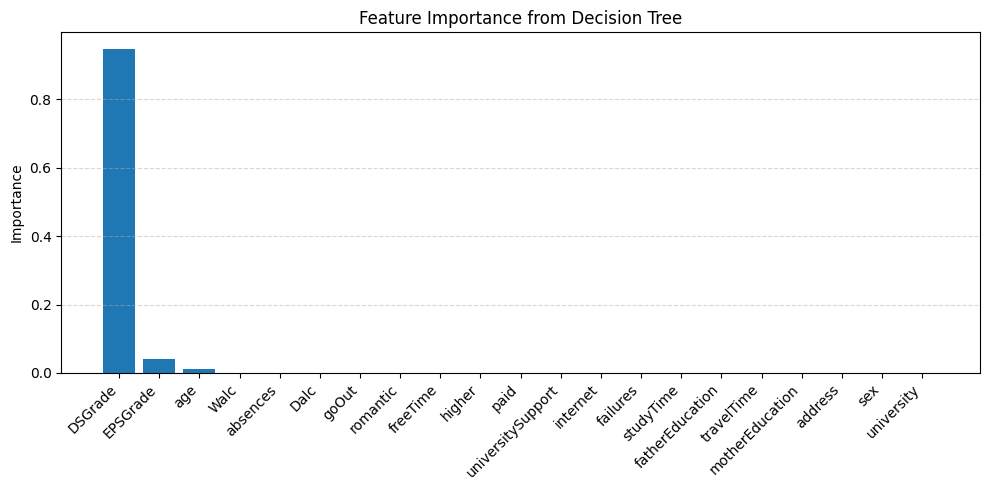

In [167]:
feature_names = df.drop(columns=["finalGrade"]).columns
importances = best_model.feature_importances_

indices = np.argsort(importances)[::-1]
sorted_features = feature_names[indices]
sorted_importances = importances[indices]

plt.figure(figsize=(10, 5))
plt.bar(range(len(sorted_features)), sorted_importances, align="center")
plt.xticks(range(len(sorted_features)), sorted_features, rotation=45, ha="right")
plt.title("Feature Importance from Decision Tree")
plt.ylabel("Importance")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


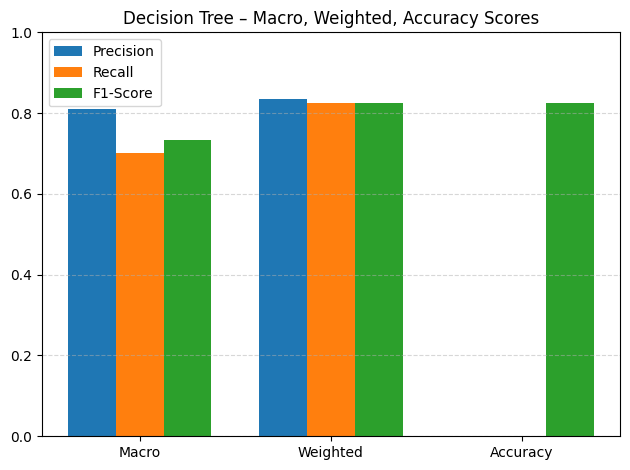

In [168]:
report = classification_report(y_test, y_pred, output_dict=True)

averages = ["macro avg", "weighted avg"]
labels = ["precision", "recall", "f1-score"]

data = {label: [report[avg][label] for avg in averages] for label in labels}
data["f1-score"].append(report["accuracy"])  # اضافه‌کردن Accuracy

x_labels = ["Macro", "Weighted", "Accuracy"]
x = np.arange(len(x_labels))
width = 0.25

fig, ax = plt.subplots()
ax.bar(x - width, data["precision"] + [0], width, label="Precision")
ax.bar(x, data["recall"] + [0], width, label="Recall")
ax.bar(x + width, data["f1-score"], width, label="F1-Score")

ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_ylim(0, 1)
ax.set_title("Decision Tree – Macro, Weighted, Accuracy Scores")
ax.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

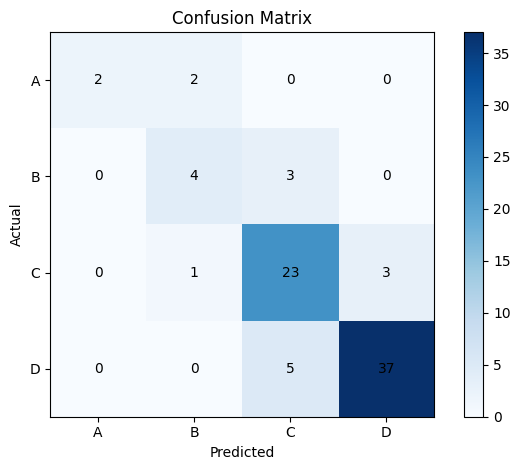

In [169]:
cm = confusion_matrix(y_test, y_pred)

labels = ["A", "B", "C", "D"]

fig, ax = plt.subplots()
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.colorbar(im)
plt.tight_layout()
plt.show()


## Random Forest

In [170]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_tree = rf_model.predict(X_test)

#print("Accuracy:", accuracy_score(y_test, y_pred_rf))

### Evaluation of Random Forest

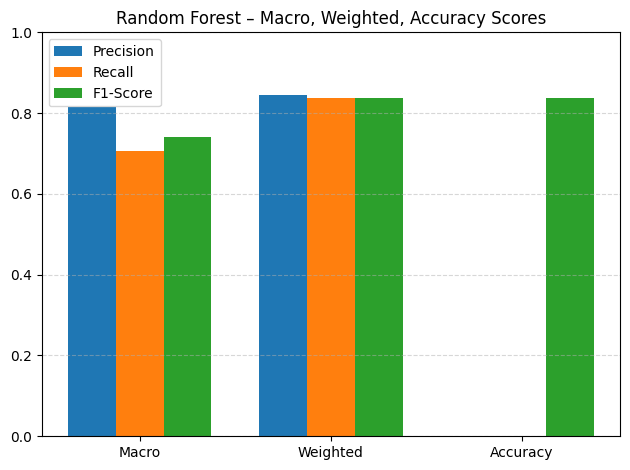

In [171]:
report = classification_report(y_test, y_pred_tree, output_dict=True)

averages = ["macro avg", "weighted avg"]
labels = ["precision", "recall", "f1-score"]

data = {label: [report[avg][label] for avg in averages] for label in labels}
data["f1-score"].append(report["accuracy"])  # اضافه‌کردن Accuracy

x_labels = ["Macro", "Weighted", "Accuracy"]
x = np.arange(len(x_labels))
width = 0.25

fig, ax = plt.subplots()
ax.bar(x - width, data["precision"] + [0], width, label="Precision")
ax.bar(x, data["recall"] + [0], width, label="Recall")
ax.bar(x + width, data["f1-score"], width, label="F1-Score")

ax.set_xticks(x)
ax.set_xticklabels(x_labels)
ax.set_ylim(0, 1)
ax.set_title("Random Forest – Macro, Weighted, Accuracy Scores")
ax.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

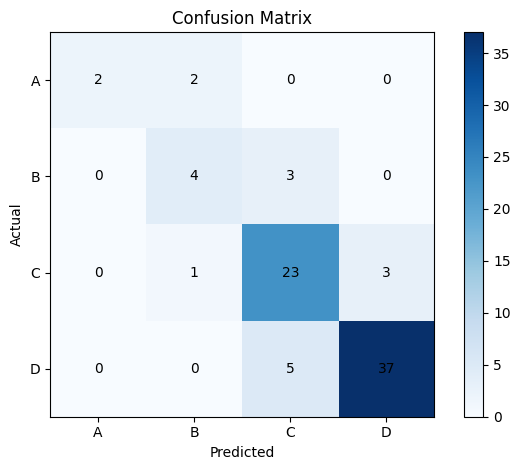

In [172]:
cm = confusion_matrix(y_test, y_pred)

labels = ["A", "B", "C", "D"]

fig, ax = plt.subplots()
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.colorbar(im)
plt.tight_layout()
plt.show()


## XGBoost

In [173]:
from xgboost import XGBClassifier
from sklearn.model_selection import GridSearchCV

xgb = XGBClassifier(objective='multi:softmax', num_class=4, eval_metric='mlogloss', random_state=42)

param_grid = {
    'learning_rate': [0.01, 0.1, 0.2],
    'n_estimators': [50, 100, 150],
    'min_child_weight': [1, 3, 5],       # معادل min_samples_leaf
    'max_depth': [3, 5, 7],
    'colsample_bytree': [0.7, 0.9, 1.0], # مشابه max_features
    'gamma': [0, 0.1, 0.2]               # تقریباً معادل min_samples_split
}

# اجرای GridSearch
grid_search = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=5,
    verbose=1,
    n_jobs=-1
)

# آموزش مدل
grid_search.fit(X_train, y_train)

# بهترین مدل
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# نتایج نهایی
print("Best Parameters:", grid_search.best_params_)
print("Accuracy:", accuracy_score(y_test, y_pred))


Fitting 5 folds for each of 729 candidates, totalling 3645 fits
Best Parameters: {'colsample_bytree': 0.7, 'gamma': 0, 'learning_rate': 0.01, 'max_depth': 3, 'min_child_weight': 3, 'n_estimators': 50}
Accuracy: 0.8375


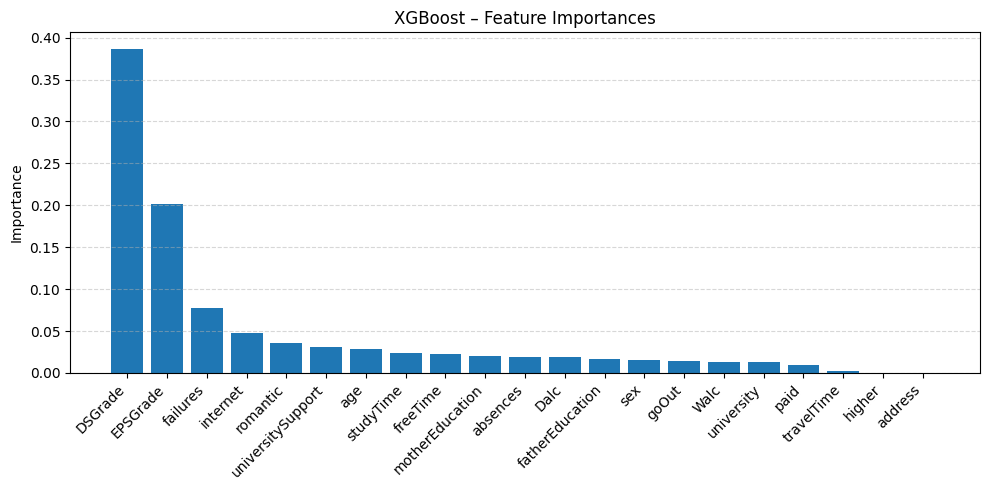

In [174]:
feature_names = df.drop(columns=["finalGrade"]).columns
importances = best_model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 5))
plt.bar(range(len(importances)), importances[indices])
plt.xticks(range(len(importances)), feature_names[indices], rotation=45, ha="right")
plt.title("XGBoost – Feature Importances")
plt.ylabel("Importance")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

### Evaluation of XGBoost 

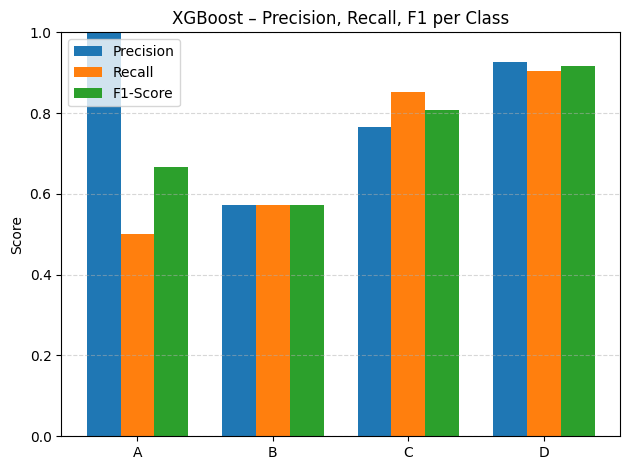

In [175]:
report = classification_report(y_test, y_pred, output_dict=True)

classes = ['0', '1', '2', '3']
class_labels = ['A', 'B', 'C', 'D']
precision = [report[c]["precision"] for c in classes]
recall = [report[c]["recall"] for c in classes]
f1_score = [report[c]["f1-score"] for c in classes]

x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots()
ax.bar(x - width, precision, width, label="Precision")
ax.bar(x, recall, width, label="Recall")
ax.bar(x + width, f1_score, width, label="F1-Score")

ax.set_xticks(x)
ax.set_xticklabels(class_labels)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("XGBoost – Precision, Recall, F1 per Class")
ax.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

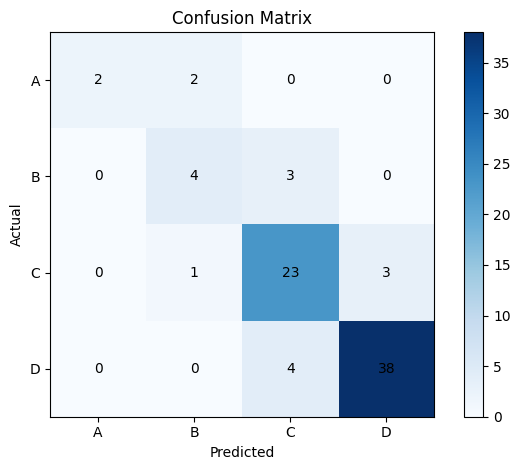

In [176]:
cm = confusion_matrix(y_test, y_pred)

labels = ["A", "B", "C", "D"]

fig, ax = plt.subplots()
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.colorbar(im)
plt.tight_layout()
plt.show()

## Decision Tree from Scratch

In [ ]:
from math import log2

class DecisionTreeID3:
    def __init__(self, max_depth = 6 , min_samples_split = 3 ,  min_gain = 0.05):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.min_gain = min_gain 
        self.tree = None


    def fit(self, X, y):
        X = X.to_dict(orient='records')
        attributes = list(X[0].keys())
       
        self.tree = self._build_tree(X, y, attributes, depth=0)

    def predict(self, X):
        X = X.to_dict(orient='records')

        return [self._traverse_tree(row, self.tree) for row in X]

    def _build_tree(self, X, y, attributes, depth):
        if len(set(y)) == 1:
            return y[0]
        if len(X) < self.min_samples_split or depth >= self.max_depth or len(attributes) == 0:
            return self._majority_class(y)
        
        best_attr = self._best_attribute(X, y, attributes)
        gain = self._information_gain(X, y, best_attr)

        if gain < self.min_gain:
            return self._majority_class(y)
        
        tree = {best_attr: {}}
        values = self._unique_vals(X, best_attr)

        for val in values:
            X_subset, y_subset = self._split(X, y, best_attr, val)
            if len(y_subset) == 0:
                tree[best_attr][val] = self._majority_class(y)
            else:
                remaining_attrs = [a for a in attributes if a != best_attr]
                tree[best_attr][val] = self._build_tree(X_subset, y_subset, remaining_attrs, depth + 1)

        return tree



    def _majority_class(self, y):
        counts = {}
        for label in y:
            counts[label] = counts.get(label, 0) + 1
        return max(counts, key=counts.get)

    def _unique_vals(self, X, attr):
        return list(set([row[attr] for row in X]))

    def _split(self, X, y, attr, value):
        X_subset, y_subset = [], []
        for i in range(len(X)):
            if X[i][attr] == value:
                X_subset.append(X[i])
                y_subset.append(y[i])
        return X_subset, y_subset

    def _entropy(self, y):
        total = len(y)
        counts = {}
        for label in y:
            counts[label] = counts.get(label, 0) + 1
        entropy = 0
        for count in counts.values():
            p = count / total
            entropy -= p * log2(p)
        return entropy

    def _information_gain(self, X, y, attr):
        base_entropy = self._entropy(y)
        values = self._unique_vals(X, attr)
        split_entropy = 0
        for val in values:
            _, y_subset = self._split(X, y, attr, val)
            if len(y_subset) == 0:
                continue
            weight = len(y_subset) / len(y)
            split_entropy += weight * self._entropy(y_subset)
        return base_entropy - split_entropy

    def _best_attribute(self, X, y, attributes):
        best_gain = -1
        best_attr = None
        for attr in attributes:
            gain = self._information_gain(X, y, attr)
            if gain > best_gain:
                best_gain = gain
                best_attr = attr
        return best_attr

    def _traverse_tree(self, row, node):
        while isinstance(node, dict):
            attr = list(node.keys())[0]
            value = row.get(attr)
            if value in node[attr]:
                node = node[attr][value]
            else:
                return None
        return node


In [199]:
import pandas as pd
from sklearn.metrics import accuracy_score

column_names = df.drop(columns=["finalGrade"]).columns
X_train = pd.DataFrame(X_train, columns=column_names)
X_test = pd.DataFrame(X_test, columns=column_names)

tree = DecisionTreeID3(max_depth=6, min_samples_split=5, min_gain=0.05)
tree.fit(X_train, y_train)
y_pred = tree.predict(X_test)

filtered_y_test = []
filtered_y_pred = []
for true, pred in zip(y_test, y_pred):
    if pred is not None:
        filtered_y_test.append(true)
        filtered_y_pred.append(pred)

accuracy = accuracy_score(filtered_y_test, filtered_y_pred)
print(f"Accuracy after pruning: {accuracy:.2f}")


Accuracy after pruning: 0.78


### Evaluation of Decision Tree from Scratch

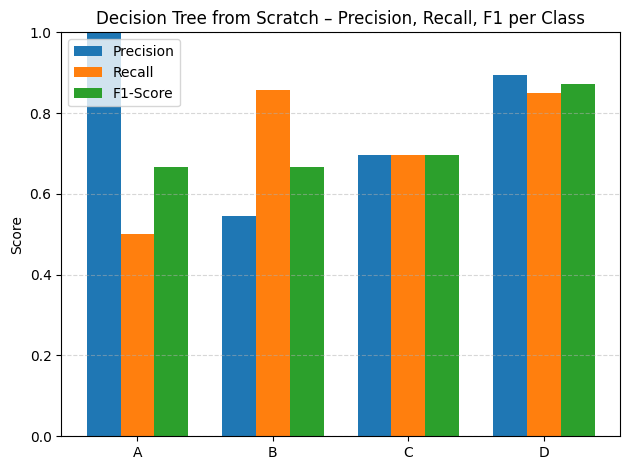

In [191]:
report = classification_report(filtered_y_test, filtered_y_pred, output_dict=True)

classes = ['0', '1', '2', '3']
class_labels = ['A', 'B', 'C', 'D']
precision = [report[c]["precision"] for c in classes]
recall = [report[c]["recall"] for c in classes]
f1_score = [report[c]["f1-score"] for c in classes]

x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots()
ax.bar(x - width, precision, width, label="Precision")
ax.bar(x, recall, width, label="Recall")
ax.bar(x + width, f1_score, width, label="F1-Score")

ax.set_xticks(x)
ax.set_xticklabels(class_labels)
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("Decision Tree from Scratch – Precision, Recall, F1 per Class")
ax.legend()
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

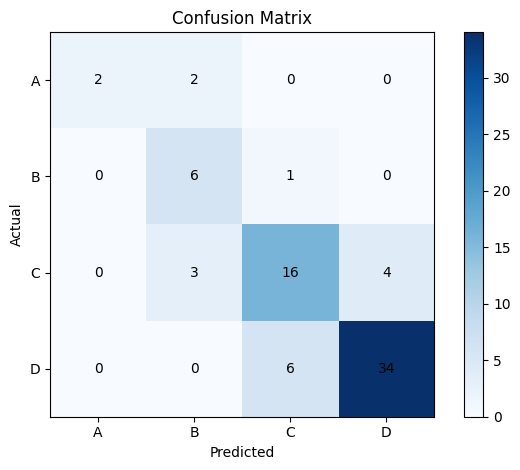

In [192]:
cm = confusion_matrix(filtered_y_test, filtered_y_pred)

labels = ["A", "B", "C", "D"]

fig, ax = plt.subplots()
im = ax.imshow(cm, cmap="Blues")

ax.set_xticks(np.arange(len(labels)))
ax.set_yticks(np.arange(len(labels)))
ax.set_xticklabels(labels)
ax.set_yticklabels(labels)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.colorbar(im)
plt.tight_layout()
plt.show()

## Comparison

In [195]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report

model = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=5,
    random_state=42
)

model.fit(X_train, y_train)

y_pred_sklearn = model.predict(X_test)

print("Accuracy (scikit-learn):", accuracy_score(y_test, y_pred_sklearn))



Accuracy (scikit-learn): 0.8125
